Keys detected in first file: ['data', 'freq_range', 'indices', 'labels', 'time_range', 'timestamps']

[LOAD] ../lofar-runs/cdcgan/(H5.1500 T2)job_28687538/out/synthetic_type2_1500.h5
  data shape: (1500, 800, 500), N=1500

[LOAD] ../lofar-runs/cdcgan/(H5.1500 T5 lil ovrfit)job_28693045/out/synthetic_type15,35_1500.h5
  data shape: (1500, 800, 500), N=1500

[LOAD] ../lofar-runs/cdcgan/(H5.1500 T4,14)job_28687537/out/synthetic_type4,14_1500.h5
  data shape: (1500, 800, 500), N=1500

[LOAD] ../../../project/lofarsw/Data/Dynspec/labelled_dataset_7classes_filtered.h5
  data shape: (6555, 800, 500), N=6555

Total samples across all files: 11055
[COMBINE] data: final shape (11055, 800, 500), dtype float32
[COMBINE] freq_range: final shape (11055, 2), dtype float64
[COMBINE] labels: final shape (11055,), dtype |S21
[COMBINE] time_range: final shape (11055, 2), dtype float64
[COMBINE] timestamps: final shape (11055,), dtype |S34
[COMBINE] indices: shape (11055,), dtype int64

[WRITE] Creating c

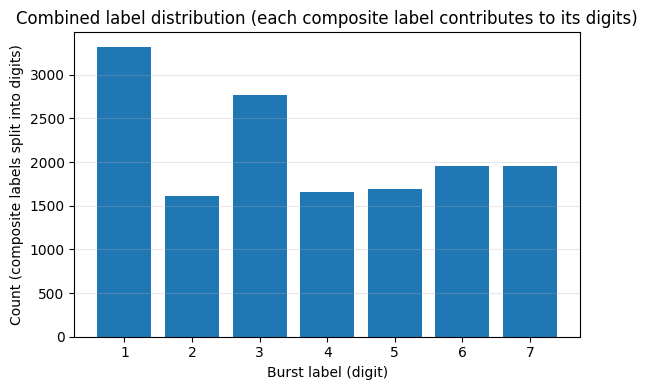

In [1]:
import os
import h5py
import numpy as np
import matplotlib.pyplot as plt
from collections import defaultdict

# ---------------- Config ----------------
# EDIT THESE PATHS
input_paths = [
    # synthetic H5 files
    "../lofar-runs/cdcgan/(H5.1500 T2)job_28687538/out/synthetic_type2_1500.h5",
     "../lofar-runs/cdcgan/(H5.1500 T5 lil ovrfit)job_28693045/out/synthetic_type15,35_1500.h5",
     "../lofar-runs/cdcgan/(H5.1500 T4,14)job_28687537/out/synthetic_type4,14_1500.h5",

    # original 7-label H5
    "../../../project/lofarsw/Data/Dynspec/labelled_dataset_7classes_filtered.h5",
]

out_path = "../../../project/lofarsw/Data/Dynspec/labelled_dataset_7classes_final.h5"

# ---------------- Merge H5 files ----------------

# Inspect keys in the first file
with h5py.File(input_paths[0], "r") as f0:
    all_keys = list(f0.keys())
print("Keys detected in first file:", all_keys)

# We'll treat any dataset whose first dimension matches N_data as per-sample.
# "data" defines N_data per file.
per_sample_arrays = {k: [] for k in all_keys if k != "indices"}
total_samples = 0

for path in input_paths:
    print(f"\n[LOAD] {path}")
    with h5py.File(path, "r") as f:
        if "data" not in f:
            raise RuntimeError(f"'data' dataset missing in file: {path}")
        data = f["data"][:]
        N = data.shape[0]
        total_samples += N
        print(f"  data shape: {data.shape}, N={N}")

        # For all keys except indices, we assume per-sample and concat along axis=0
        for k in per_sample_arrays.keys():
            arr = f[k][:]
            if arr.shape[0] != N:
                raise RuntimeError(
                    f"Key '{k}' in file {path} has first dimension {arr.shape[0]} "
                    f"but 'data' has {N}. I expect per-sample datasets."
                )
            per_sample_arrays[k].append(arr)

print(f"\nTotal samples across all files: {total_samples}")

# Concatenate per-sample datasets
combined = {}
for k, parts in per_sample_arrays.items():
    combined[k] = np.concatenate(parts, axis=0)
    print(f"[COMBINE] {k}: final shape {combined[k].shape}, dtype {combined[k].dtype}")

# Sanity check
if combined["data"].shape[0] != total_samples:
    raise RuntimeError("Mismatch: combined data length != total_samples.")

N_total = total_samples

# Build new indices: 0..N_total-1
combined["indices"] = np.arange(N_total, dtype=np.int64)
print(f"[COMBINE] indices: shape {combined['indices'].shape}, dtype {combined['indices'].dtype}")

# ---------------- Write combined H5 ----------------
os.makedirs(os.path.dirname(out_path), exist_ok=True)
print(f"\n[WRITE] Creating combined file at: {out_path}")

with h5py.File(out_path, "w") as f_out:
    for k, arr in combined.items():
        # Force float32 for data (you said generated data & input data are float32)
        if k == "data":
            arr = arr.astype(np.float32, copy=False)
        dset = f_out.create_dataset(
            k,
            data=arr,
            compression="gzip",
            shuffle=True,
        )
        print(f"  wrote dataset '{k}' -> shape {arr.shape}, dtype {arr.dtype}")

print("[WRITE] Done.")

# ---------------- Label distribution (composite → digits) ----------------

# We now read labels from the combined file and build a bar chart
with h5py.File(out_path, "r") as f:
    labels_raw = f["labels"][:]

print("\n[STATS] labels_raw shape:", labels_raw.shape, "dtype:", labels_raw.dtype)

# Count per burst digit: label 13 -> +1 for 1 and +1 for 3, 135 -> +1 for 1, 3, 5
digit_counts = defaultdict(int)

for lb in labels_raw:
    # Robust to bytes, numpy scalar, etc.
    if isinstance(lb, (bytes, bytearray, np.bytes_)):
        s = lb.decode()
    else:
        # treat as integer code like 1, 2, 3, 13, 135, ...
        s = str(int(lb))

    for ch in s:
        # skip zeros if they appear (e.g., 0 for "no burst")
        if ch == "0":
            continue
        if not ch.isdigit():
            continue
        digit = int(ch)
        digit_counts[digit] += 1

# Sort digits (burst types) numerically
burst_types = sorted(digit_counts.keys())
counts = [digit_counts[d] for d in burst_types]

print("\n[STATS] Composite-split label counts (each digit in label counted once):")
for d in burst_types:
    print(f"  burst {d}: {digit_counts[d]}")

# ---------------- Plot bar chart ----------------
fig, ax = plt.subplots(figsize=(6, 4))
x = np.arange(len(burst_types))

ax.bar(x, counts)
ax.set_xticks(x)
ax.set_xticklabels([str(d) for d in burst_types])
ax.set_xlabel("Burst label (digit)")
ax.set_ylabel("Count (composite labels split into digits)")
ax.set_title("Combined label distribution (each composite label contributes to its digits)")
ax.grid(alpha=0.3, axis="y")

plt.tight_layout()

# Save to file + show
plot_path = os.path.splitext(out_path)[0] + "_label_distribution.png"
plt.savefig(plot_path, dpi=150)
print(f"\n[WRITE] Saved label distribution bar chart to: {plot_path}")
plt.show()
